In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import time
print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
BATCH_SIZE = 64

# Define a transform to binarize the data
class BinarizeTransform:
    def __call__(self, img_tensor):
        # Binarize the tensor: 1 if pixel > 0.5, 0 otherwise
        # torch.bernoulli samples from a [0, 1] distribution
        # This is a common way to binarize for RBMs
        return torch.bernoulli(img_tensor)

transform = transforms.Compose([
    transforms.ToTensor(),
    # BinarizeTransform() # We will binarize inside the training loop
])

train_dataset = torchvision.datasets.MNIST(root='./data', 
                                           train=True, 
                                           transform=transform, 
                                           download=True)
train_loader = DataLoader(dataset=train_dataset, 
                          batch_size=BATCH_SIZE, 
                          shuffle=True)

test_dataset = torchvision.datasets.MNIST(root='./data', 
                                          train=False, 
                                          transform=transform,
                                          download=True)
test_loader = DataLoader(dataset=test_dataset, 
                         batch_size=BATCH_SIZE, 
                         shuffle=False)

print(f"Loaded {len(train_dataset)} training images.")

Loaded 60000 training images.


In [3]:
class RBM(nn.Module):
    def __init__(self, n_visible, n_hidden):
        super(RBM, self).__init__()
        self.n_visible = n_visible  # Number of visible units (e.g., 784)
        self.n_hidden = n_hidden    # Number of hidden units (e.g., 500)
        
        # Initialize weights and biases
        self.W = nn.Parameter(torch.randn(n_hidden, n_visible) * 0.01)
        self.h_bias = nn.Parameter(torch.zeros(n_hidden))
        self.v_bias = nn.Parameter(torch.zeros(n_visible))
    
    def sample_h(self, v):
        """
        Given visible units, sample the hidden units.
        v: [batch_size, n_visible]
        """
        # Calculate P(h=1|v) = sigmoid(v * W.T + h_bias)
        p_h_given_v = torch.sigmoid(torch.matmul(v, self.W.T) + self.h_bias)
        # Sample hidden states (binary) from this probability
        h_sample = torch.bernoulli(p_h_given_v)
        return p_h_given_v, h_sample

    def sample_v(self, h):
        """
        Given hidden units, sample the visible units (reconstruction).
        h: [batch_size, n_hidden]
        """
        # Calculate P(v=1|h) = sigmoid(h * W + v_bias)
        p_v_given_h = torch.sigmoid(torch.matmul(h, self.W) + self.v_bias)
        # Sample visible states (binary) from this probability
        v_sample = torch.bernoulli(p_v_given_h)
        return p_v_given_h, v_sample

    def forward(self, v):
        """
        This is one step of Gibbs sampling, used in Contrastive Divergence.
        v -> h0 -> v1
        """
        _, h0 = self.sample_h(v)
        _, v1 = self.sample_v(h0)
        return v1
    
    def contrastive_divergence(self, v0, k=1):
        """
        Perform k-step Contrastive Divergence (CD-k).
        v0: [batch_size, n_visible] - The original input data
        """
        # 1. Positive Phase (from data)
        # Get hidden probabilities and samples from the real data (v0)
        p_h0, h0 = self.sample_h(v0)
        
        # 2. Negative Phase (from reconstruction)
        # Start Gibbs sampling chain
        vk = v0
        hk = h0
        for _ in range(k):
            # Sample v from h
            _, vk = self.sample_v(hk)
            # Sample h from v
            _, hk = self.sample_h(vk)
        
        # 3. Get probabilities for the final reconstructed visible units
        p_hk, _ = self.sample_h(vk)
        
        # 4. Calculate gradients (we do this manually)
        # We don't use loss.backward()
        
        # Positive gradient component (from data)
        pos_W_grad = torch.matmul(p_h0.T, v0)
        pos_v_bias_grad = v0.sum(dim=0)
        pos_h_bias_grad = p_h0.sum(dim=0)
        
        # Negative gradient component (from reconstruction)
        neg_W_grad = torch.matmul(p_hk.T, vk)
        neg_v_bias_grad = vk.sum(dim=0)
        neg_h_bias_grad = p_hk.sum(dim=0)
        
        # Calculate update and update weights (like a manual optimizer)
        batch_size = v0.shape[0]
        self.W.data += self.lr * (pos_W_grad - neg_W_grad) / batch_size
        self.v_bias.data += self.lr * (pos_v_bias_grad - neg_v_bias_grad) / batch_size
        self.h_bias.data += self.lr * (pos_h_bias_grad - neg_h_bias_grad) / batch_size
        
        # Return reconstruction error
        error = torch.mean((v0 - vk)**2)
        return error

print("RBM class defined.")

RBM class defined.


Starting RBM training... (n_visible=784, n_hidden=500)
Epoch [1/50], Reconstruction Error: 0.0913, Time: 10.66s
Epoch [2/50], Reconstruction Error: 0.0641, Time: 13.22s
Epoch [3/50], Reconstruction Error: 0.0571, Time: 13.50s
Epoch [4/50], Reconstruction Error: 0.0533, Time: 12.62s
Epoch [5/50], Reconstruction Error: 0.0508, Time: 12.65s
Epoch [6/50], Reconstruction Error: 0.0491, Time: 14.67s
Epoch [7/50], Reconstruction Error: 0.0479, Time: 13.51s
Epoch [8/50], Reconstruction Error: 0.0469, Time: 13.25s
Epoch [9/50], Reconstruction Error: 0.0461, Time: 12.28s
Epoch [10/50], Reconstruction Error: 0.0455, Time: 12.22s
Epoch [11/50], Reconstruction Error: 0.0450, Time: 12.46s
Epoch [12/50], Reconstruction Error: 0.0445, Time: 13.39s
Epoch [13/50], Reconstruction Error: 0.0441, Time: 12.48s
Epoch [14/50], Reconstruction Error: 0.0438, Time: 12.34s
Epoch [15/50], Reconstruction Error: 0.0435, Time: 14.02s
Epoch [16/50], Reconstruction Error: 0.0433, Time: 14.53s
Epoch [17/50], Reconstruct

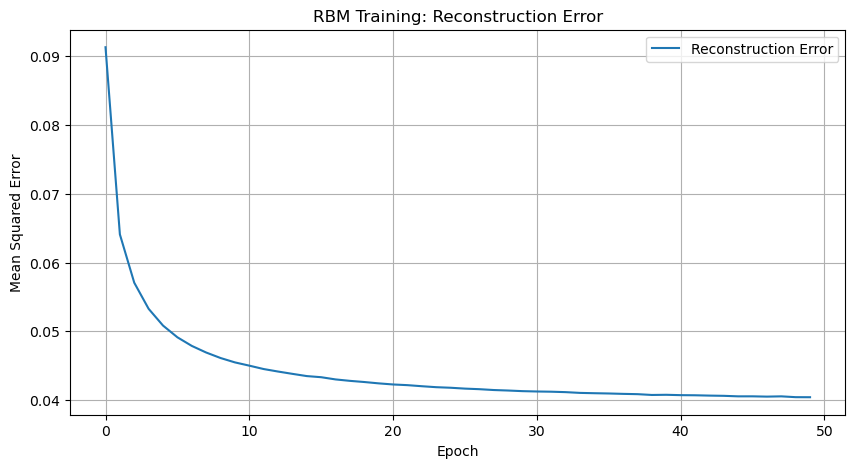

In [4]:
# RBM Hyperparameters
N_VISIBLE = 28 * 28  # 784
N_HIDDEN = 500       # Number of hidden "features" to learn
K_CD = 1             # Steps of Contrastive Divergence (CD-1 is common)
LEARNING_RATE = 0.1
NUM_EPOCHS = 50


# Instantiate the RBM
rbm = RBM(N_VISIBLE, N_HIDDEN)
rbm.lr = LEARNING_RATE # Set learning rate on the model instance

print(f"Starting RBM training... (n_visible={N_VISIBLE}, n_hidden={N_HIDDEN})")

rbm_errors = []
for epoch in range(NUM_EPOCHS):
    epoch_error = 0.0
    start_time = time.time()
    
    for i, (images, _) in enumerate(train_loader):
        # Flatten and binarize the images
        images = images.view(-1, N_VISIBLE)
        v0 = torch.bernoulli(images) # Binarize
        
        # Perform one step of CD-k and update weights
        reconstruction_error = rbm.contrastive_divergence(v0, k=K_CD)
        epoch_error += reconstruction_error.item()
    
    end_time = time.time()
    epoch_error /= len(train_loader)
    rbm_errors.append(epoch_error)
    
    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}], "
          f"Reconstruction Error: {epoch_error:.4f}, "
          f"Time: {end_time - start_time:.2f}s")

print("RBM training complete.")

# Plot the reconstruction error
plt.figure(figsize=(10, 5))
plt.plot(rbm_errors, label="Reconstruction Error")
plt.title("RBM Training: Reconstruction Error")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.legend()
plt.grid(True)
plt.show()

Generating new digits (dreaming)...


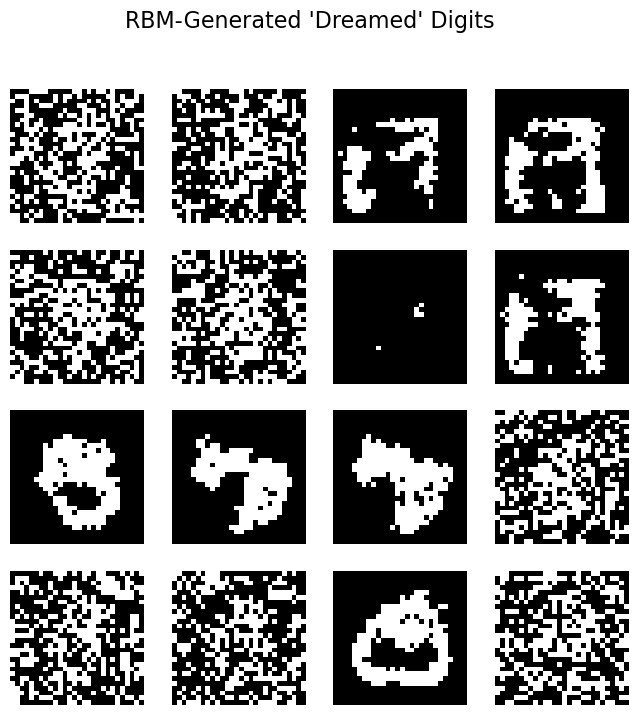

In [5]:
print("Generating new digits (dreaming)...")

# Number of images to generate
N_GENERATE = 16

# Start with random noise
# We'll generate 16 images at once
v_noise = torch.rand(N_GENERATE, N_VISIBLE)

# Run Gibbs sampling for many steps (e.g., 1000)
# This lets the RBM "settle" into a low-energy state (a "memory")
for _ in range(1000):
    # Pass the noise through the RBM
    # v -> h -> v'
    _, h_sample = rbm.sample_h(v_noise)
    _, v_noise = rbm.sample_v(h_sample)

# The final 'v_noise' is our "dreamed" image
generated_images = v_noise

# Plot the generated images
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
plt.suptitle("RBM-Generated 'Dreamed' Digits", fontsize=16)
for i, ax in enumerate(axes.flat):
    ax.imshow(generated_images[i].detach().numpy().reshape(28, 28), cmap='gray')
    ax.axis('off')

plt.show()

In [6]:
class DBNClassifier(nn.Module):
    def __init__(self, rbm):
        super(DBNClassifier, self).__init__()
        
        # 1. Store the pre-trained RBM
        self.rbm = rbm
        
        # 2. Freeze the RBM's weights
        # We don't want to train this part anymore
        for param in self.rbm.parameters():
            param.requires_grad = False
            
        # 3. Create a new, simple linear classifier
        # It takes the RBM's hidden features (n_hidden)
        # and outputs 10 classes
        self.classifier = nn.Linear(rbm.n_hidden, 10)
    
    def forward(self, x):
        # 1. Flatten the input image
        x = x.view(-1, 784)
        
        # 2. Binarize the input
        x = torch.bernoulli(x)
        
        # 3. Pass data through the RBM (UNSUPERVISED)
        # We get the *probabilities* of the hidden units
        # These are our new "features"
        p_h, _ = self.rbm.sample_h(x)
        
        # 4. Classify based on these features (SUPERVISED)
        # p_h is [batch_size, n_hidden]
        logits = self.classifier(p_h)
        return logits

print("DBN Classifier class defined.")

DBN Classifier class defined.


In [7]:
# Instantiate the DBN
dbn = DBNClassifier(rbm)

# Define loss and optimizer
# IMPORTANT: We only pass the classifier's parameters to the optimizer!
# The RBM is frozen.
optimizer = optim.Adam(dbn.classifier.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

# We can use our old evaluation function
def evaluate_model(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

print("Starting DBN (classifier) training...")

DBN_EPOCHS = 10
dbn_loss_history = []
dbn_acc_history = []

for epoch in range(DBN_EPOCHS):
    dbn.train()
    epoch_loss = 0.0
    for images, labels in train_loader:
        
        # Standard training loop
        optimizer.zero_grad()
        outputs = dbn(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
    
    epoch_loss /= len(train_loader)
    dbn_loss_history.append(epoch_loss)
    
    # Evaluate accuracy
    accuracy = evaluate_model(dbn, test_loader)
    dbn_acc_history.append(accuracy)
    
    print(f"Epoch [{epoch+1}/{DBN_EPOCHS}], "
          f"Classifier Loss: {epoch_loss:.4f}, "
          f"Test Accuracy: {accuracy:.2f}%")

print("DBN training complete.")

Starting DBN (classifier) training...
Epoch [1/10], Classifier Loss: 0.4397, Test Accuracy: 93.80%
Epoch [2/10], Classifier Loss: 0.2142, Test Accuracy: 94.98%
Epoch [3/10], Classifier Loss: 0.1785, Test Accuracy: 95.37%
Epoch [4/10], Classifier Loss: 0.1588, Test Accuracy: 95.83%
Epoch [5/10], Classifier Loss: 0.1453, Test Accuracy: 95.98%
Epoch [6/10], Classifier Loss: 0.1355, Test Accuracy: 96.16%
Epoch [7/10], Classifier Loss: 0.1276, Test Accuracy: 96.37%
Epoch [8/10], Classifier Loss: 0.1228, Test Accuracy: 96.38%
Epoch [9/10], Classifier Loss: 0.1186, Test Accuracy: 96.70%
Epoch [10/10], Classifier Loss: 0.1133, Test Accuracy: 96.53%
DBN training complete.


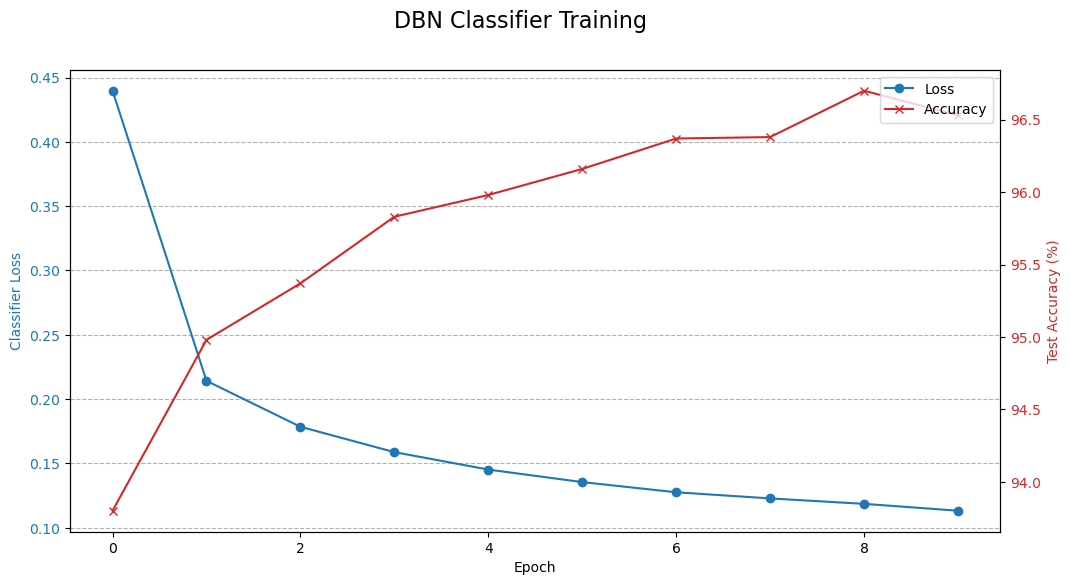

In [8]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Loss
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Classifier Loss', color='tab:blue')
ax1.plot(dbn_loss_history, color='tab:blue', label='Loss', marker='o')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(True, axis='y', linestyle='--')

# Create a second y-axis for Accuracy
ax2 = ax1.twinx()
ax2.set_ylabel('Test Accuracy (%)', color='tab:red')
ax2.plot(dbn_acc_history, color='tab:red', label='Accuracy', marker='x')
ax2.tick_params(axis='y', labelcolor='tab:red')

fig.suptitle('DBN Classifier Training', fontsize=16)
fig.legend(loc="upper right", bbox_to_anchor=(1,1), bbox_transform=ax1.transAxes)
plt.show()